In [1]:
#useful python libraries
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
#sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier

In [2]:
#load my data
df = pd.read_parquet("my_feature_space.parquet")

df.head()

,objectId,finkclass,mean,weighted_mean,standard_deviation,median,amplitude,beyond_1_std,cusum,inter_percentile_range_10,...,magnitude_percentage_ratio_20_10,maximum_slope,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,mean_variance,anderson_darling_normal,chi2,skew,stetson_K
0,ZTF17aaaadkj,CataclyV*,17.222114,17.174713,0.237890,17.224249,1.171396,0.195322,0.108385,0.481224,...,0.676086,410.613047,0.126921,0.457310,1.825376,0.013813,13.875019,242.808733,-2.438629,0.585522
1,ZTF17aaaagyq,CataclyV*,16.735330,16.498882,0.637000,16.862818,1.910264,0.197590,0.152603,1.436352,...,0.429171,354.654346,0.234251,0.414458,2.552179,0.038063,43.600593,2694.289711,-1.706663,0.709195
2,ZTF17aaaaqna,Unknown,14.323769,14.321861,0.206714,14.224896,0.440336,0.169289,0.109419,0.441297,...,0.723493,95.102274,0.062597,0.344004,0.750938,0.014432,138.605800,238.412293,1.464617,0.796598
3,ZTF17aaaarmr,CataclyV*,16.282178,16.256730,0.240892,16.229107,1.577422,0.129736,0.238448,0.418315,...,0.507220,137.920000,0.074253,0.771527,2.849228,0.014795,61.877870,121.862796,5.046224,0.701406
4,ZTF17aaaazob,CataclyV*,17.864093,17.649710,0.403722,17.859806,2.242684,0.179581,0.082159,0.778325,...,0.627876,696.187235,0.198764,0.561076,3.199834,0.022600,49.381505,620.820245,-2.514259,0.488813


In [3]:
#check shape
df.shape

(2059, 28)

In [4]:
# 1 = CataclyV (including candidates)
# 0 = everything else

y_true = df['finkclass'].apply(
    lambda x: 1 if 'Cat' in str(x) else 0     #true class title
).values

print("Class distribution:")

Class distribution:


In [5]:
# Load saved model
model = joblib.load("cv_classifier_xgb_boost_biggie_set.pkl")

In [6]:
#feature space
feature_columns = df.drop(columns=['objectId', 'finkclass']).columns #drop non_numeric columns

X = df[feature_columns].values #feature column

In [7]:
y_pred = model.predict(X) #predict model

In [8]:
print("Unique predictions:", np.unique(y_pred)) #cross check

Unique predictions: [0 1]


In [9]:
# Check class probabilities for the test set.
# predict_proba returns an array of shape (N_test, 2),
# where N_test is the number of test objects.
# Column 0 : probability of class 0 (negative, unknown)
# Column 1 : probability of class +1 (positive, cvs)
probs = model.predict_proba(X)
print('probs',probs)

probs [[0.0235793  0.9764207 ]
 [0.50654924 0.4934508 ]
 [0.9499782  0.05002185]
 ...
 [0.6744125  0.32558754]
 [0.96295    0.03705003]
 [0.93687785 0.06312215]]


In [10]:
# CV probability
cv_prob = probs[:,1]

# create dataframe for attaching objectid
prob_df = pd.DataFrame({
    "objectId": df["objectId"],
    "cv_probability": cv_prob
})
#check output
print(prob_df.head())

       objectId  cv_probability
0  ZTF17aaaadkj        0.976421
1  ZTF17aaaagyq        0.493451
2  ZTF17aaaaqna        0.050022
3  ZTF17aaaarmr        0.352061
4  ZTF17aaaazob        0.974279


In [11]:
# CV probability with finkclass_column_atached
cv_prob = probs[:,1]

# create dataframe with required columns
prob_df = pd.DataFrame({
    "objectId": df["objectId"],
    "finkclass": df["finkclass"],
    "cv_probability": cv_prob
})

# check
print(prob_df.head())

       objectId  finkclass  cv_probability
0  ZTF17aaaadkj  CataclyV*        0.976421
1  ZTF17aaaagyq  CataclyV*        0.493451
2  ZTF17aaaaqna    Unknown        0.050022
3  ZTF17aaaarmr  CataclyV*        0.352061
4  ZTF17aaaazob  CataclyV*        0.974279


In [12]:
#saving into parquet
prob_df.to_parquet("class prediction.parquet", index=False)

In [19]:
prob_df

,objectId,finkclass,cv_probability
0,ZTF17aaaadkj,CataclyV*,0.976421
1,ZTF17aaaagyq,CataclyV*,0.493451
2,ZTF17aaaaqna,Unknown,0.050022
3,ZTF17aaaarmr,CataclyV*,0.352061
4,ZTF17aaaazob,CataclyV*,0.974279
...,...,...,...
2054,ZTF26aaajqnu,CataclyV*,0.992168
2055,ZTF26aaaombw,Unknown,0.022897
2056,ZTF26aabsgfq,Unknown,0.325588
2057,ZTF26aaewgqp,Unknown,0.037050


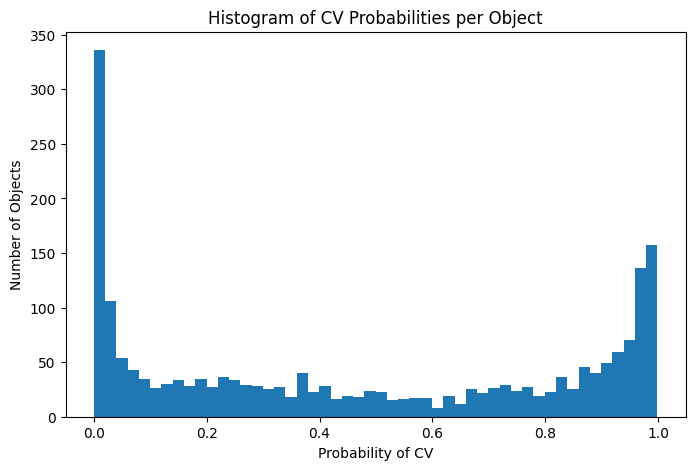

In [13]:
#plotting histogram
plt.figure(figsize=(8,5)) #fig size
plt.hist(prob_df["cv_probability"], bins=50)
#plt.axvline(0.5, linestyle="--", label="0.5 threshold") #threshold
#plotting
plt.xlabel("Probability of CV")
plt.ylabel("Number of Objects")
plt.title("Histogram of CV Probabilities per Object")
#plt.legend()

plt.show()

In [14]:
#probablity distribution checking
high_prob = prob_df[prob_df["cv_probability"] > 0.5]
print("Number of objects with CV probability > 0.5:", len(high_prob))

Number of objects with CV probability > 0.5: 940


In [15]:
#attach objectid
print(high_prob["objectId"])

0       ZTF17aaaadkj
4       ZTF17aaaazob
6       ZTF17aaabavb
7       ZTF17aaabfay
8       ZTF17aaabfbg
            ...     
2045    ZTF25abungcd
2047    ZTF25acfrkfu
2048    ZTF25achwolj
2051    ZTF26aaaelef
2054    ZTF26aaajqnu
Name: objectId, Length: 940, dtype: object


In [16]:
#saving into parquet
high_prob.to_parquet("cv_candidates_above_0.5.parquet", index=False)

In [17]:
#Reading parquet
df_prob=pd.read_parquet("cv_candidates_above_0.5.parquet")

In [18]:
df_prob

,objectId,finkclass,cv_probability
0,ZTF17aaaadkj,CataclyV*,0.976421
1,ZTF17aaaazob,CataclyV*,0.974279
2,ZTF17aaabavb,CataclyV*,0.978210
3,ZTF17aaabfay,CataclyV*,0.862972
4,ZTF17aaabfbg,CataclyV*,0.588050
...,...,...,...
935,ZTF25abungcd,CataclyV*,0.998523
936,ZTF25acfrkfu,Unknown,0.621128
937,ZTF25achwolj,Unknown,0.717575
938,ZTF26aaaelef,CataclyV*,0.972862
